# Phishing Dataset Analysis

This notebook performs Phase 2 dataset inspection and exploratory data analysis using only `dataset/raw/phishing_dataset.csv`. The raw file is never overwritten.

The dataset schema is discovered from the CSV at runtime; `Result` is used as the target because it is the observed class/result column in this dataset.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "dataset" / "raw" / "phishing_dataset.csv").exists() and PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_PATH = PROJECT_ROOT / "dataset" / "raw" / "phishing_dataset.csv"
PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_PATH)
print(f"Loaded: {RAW_PATH}")
print(f"Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded: C:\Users\gjhus\.copilot\repos\copilot-worktrees\EbankingPhishingDetection\gaddamjhushiketh-studious-succotash\dataset\raw\phishing_dataset.csv
Dimensions: 1353 rows x 10 columns


,SFH,popUpWidnow,SSLfinal_State,Request_URL,URL_of_Anchor,web_traffic,URL_Length,age_of_domain,having_IP_Address,Result
0,1,-1,1,-1,-1,1,1,1,0,0
1,-1,-1,-1,-1,-1,0,1,1,1,1
2,1,-1,0,0,-1,0,-1,1,0,1
3,1,0,1,-1,-1,0,1,1,0,0
4,-1,-1,1,-1,0,0,-1,1,0,1


## 1. Schema and data types

In [2]:
print("Exact column names:")
print(list(df.columns))
print("\nData types:")
print(df.dtypes.to_frame("dtype"))
print("\nDataFrame info:")
df.info()

Exact column names:
['SFH', 'popUpWidnow', 'SSLfinal_State', 'Request_URL', 'URL_of_Anchor', 'web_traffic', 'URL_Length', 'age_of_domain', 'having_IP_Address', 'Result']

Data types:
                   dtype
SFH                int64
popUpWidnow        int64
SSLfinal_State     int64
Request_URL        int64
URL_of_Anchor      int64
web_traffic        int64
URL_Length         int64
age_of_domain      int64
having_IP_Address  int64
Result             int64

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   SFH                1353 non-null   int64
 1   popUpWidnow        1353 non-null   int64
 2   SSLfinal_State     1353 non-null   int64
 3   Request_URL        1353 non-null   int64
 4   URL_of_Anchor      1353 non-null   int64
 5   web_traffic        1353 non-null   int64
 6   URL_Length         1353 non-null   int64
 7  

## 2. Missing values, duplicates, and unique values

In [3]:
missing = df.isna().sum().rename("missing_count").to_frame()
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(4)
print("Missing values:")
display(missing)

exact_duplicate_count = int(df.duplicated().sum())
print(f"Exact duplicate records: {exact_duplicate_count} ({exact_duplicate_count / len(df) * 100:.4f}%)")
print(f"Rows remaining after exact-row deduplication: {len(df.drop_duplicates())}")

unique_counts = df.nunique(dropna=False).rename("unique_count").to_frame()
print("\nUnique-value counts:")
display(unique_counts)

print("Unique values by column:")
for column in df.columns:
    print(f"{column}: {sorted(df[column].dropna().unique().tolist())}")

Missing values:


,missing_count,missing_percent
SFH,0,0.0
popUpWidnow,0,0.0
SSLfinal_State,0,0.0
Request_URL,0,0.0
URL_of_Anchor,0,0.0
web_traffic,0,0.0
URL_Length,0,0.0
age_of_domain,0,0.0
having_IP_Address,0,0.0
Result,0,0.0


Exact duplicate records: 629 (46.4893%)
Rows remaining after exact-row deduplication: 724

Unique-value counts:


,unique_count
SFH,3
popUpWidnow,3
SSLfinal_State,3
Request_URL,3
URL_of_Anchor,3
web_traffic,3
URL_Length,3
age_of_domain,2
having_IP_Address,2
Result,3


Unique values by column:
SFH: [-1, 0, 1]
popUpWidnow: [-1, 0, 1]
SSLfinal_State: [-1, 0, 1]
Request_URL: [-1, 0, 1]
URL_of_Anchor: [-1, 0, 1]
web_traffic: [-1, 0, 1]
URL_Length: [-1, 0, 1]
age_of_domain: [-1, 1]
having_IP_Address: [0, 1]
Result: [-1, 0, 1]


## 3. Target/class distribution

Target column: Result


,count,percent
Result,,
-1,702,51.8847
0,103,7.6127
1,548,40.5026


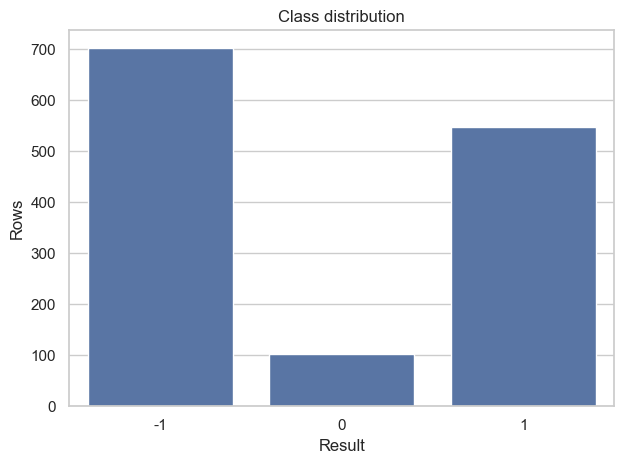

In [4]:
TARGET_COLUMN = "Result"
if TARGET_COLUMN not in df.columns:
    raise KeyError(f"Expected observed target column {TARGET_COLUMN!r} was not found")

target_distribution = df[TARGET_COLUMN].value_counts(dropna=False).sort_index().rename("count").to_frame()
target_distribution["percent"] = (target_distribution["count"] / len(df) * 100).round(4)
print(f"Target column: {TARGET_COLUMN}")
display(target_distribution)

ax = sns.countplot(data=df, x=TARGET_COLUMN, order=sorted(df[TARGET_COLUMN].dropna().unique()))
ax.set_title("Class distribution")
ax.set_xlabel(TARGET_COLUMN)
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

## 4. Descriptive statistics

In [5]:
descriptive_statistics = df.describe(include="all").transpose()
display(descriptive_statistics)

,count,mean,std,min,25%,50%,75%,max
SFH,1353.0,0.237990,0.916389,-1.0,-1.0,1.0,1.0,1.0
popUpWidnow,1353.0,-0.258684,0.679072,-1.0,-1.0,0.0,0.0,1.0
SSLfinal_State,1353.0,0.327421,0.822193,-1.0,0.0,1.0,1.0,1.0
Request_URL,1353.0,-0.223208,0.799682,-1.0,-1.0,0.0,0.0,1.0
URL_of_Anchor,1353.0,-0.025129,0.936262,-1.0,-1.0,0.0,1.0,1.0
web_traffic,1353.0,0.000000,0.806776,-1.0,-1.0,0.0,1.0,1.0
URL_Length,1353.0,-0.053215,0.762552,-1.0,-1.0,0.0,1.0,1.0
age_of_domain,1353.0,0.219512,0.975970,-1.0,-1.0,1.0,1.0,1.0
having_IP_Address,1353.0,0.114560,0.318608,0.0,0.0,0.0,0.0,1.0
Result,1353.0,-0.113821,0.954773,-1.0,-1.0,-1.0,1.0,1.0


## 5. Feature distributions and relationships

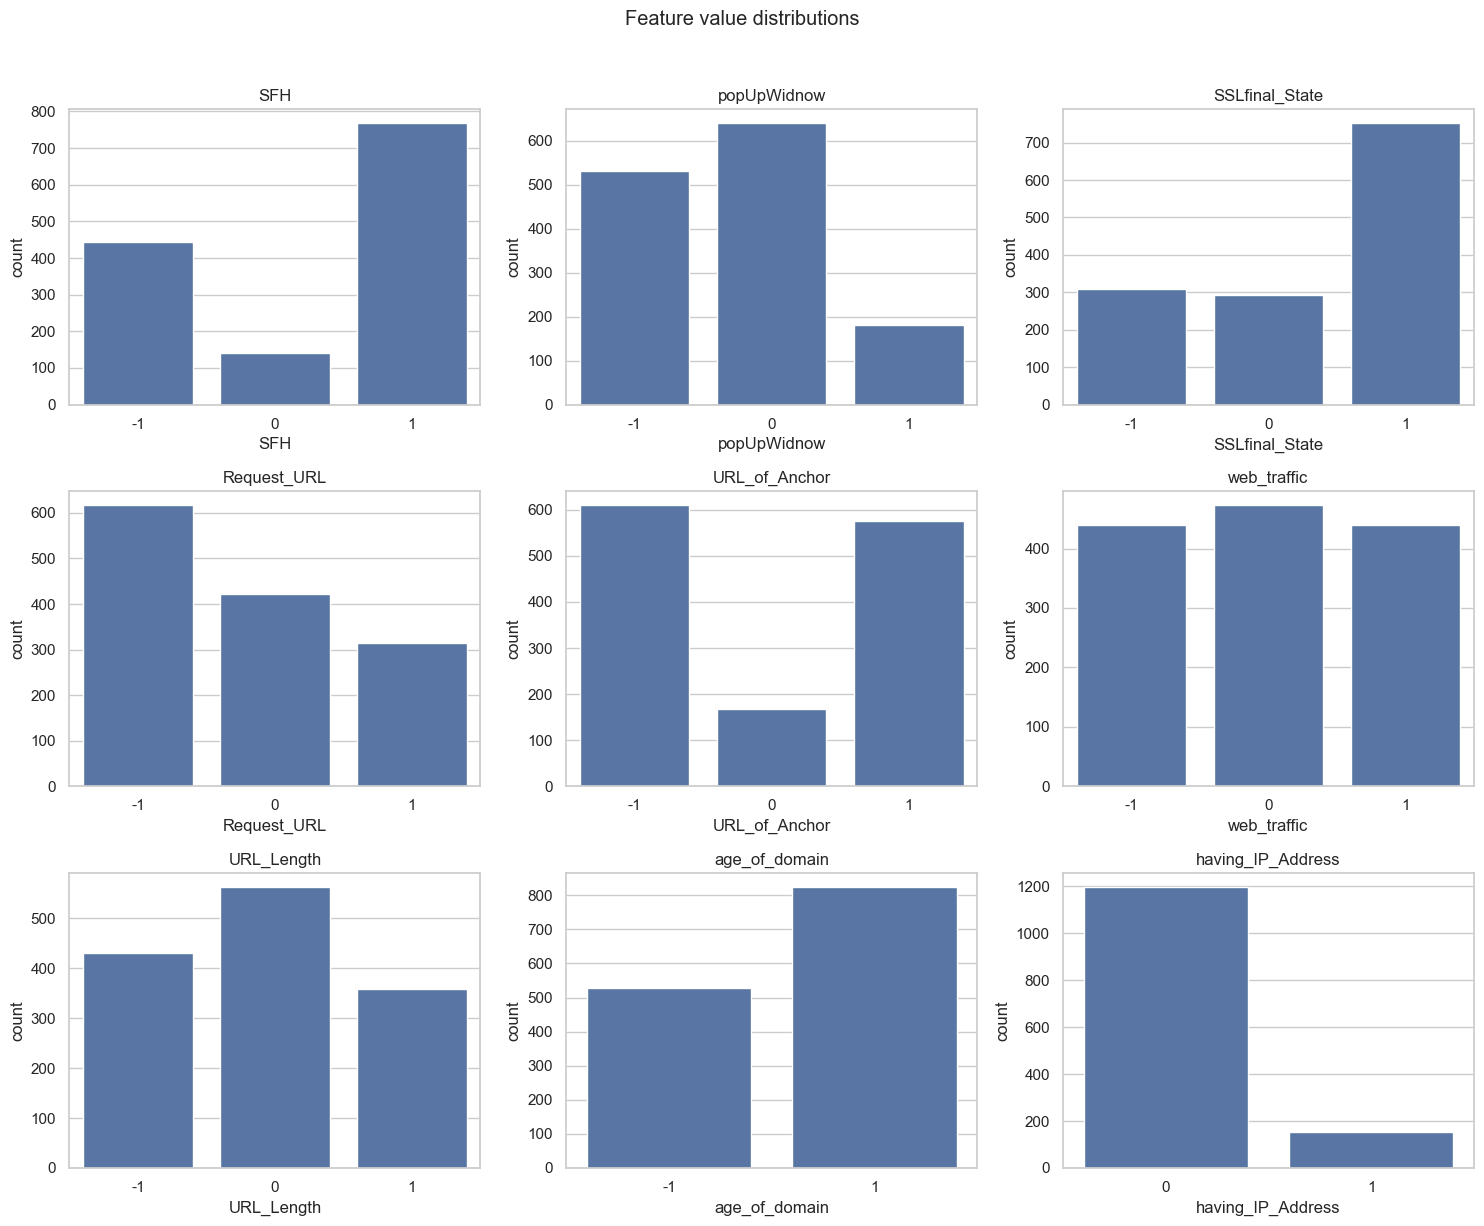

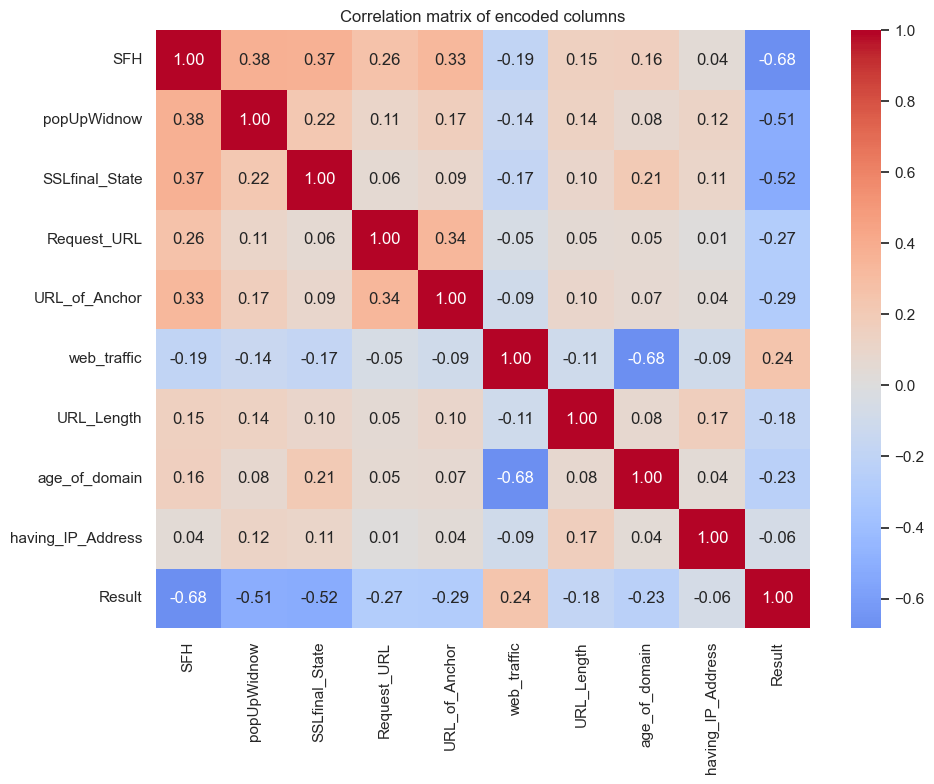

In [6]:
feature_columns = [column for column in df.columns if column != TARGET_COLUMN]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for axis, column in zip(axes.flat, feature_columns):
    sns.countplot(data=df, x=column, order=sorted(df[column].dropna().unique()), ax=axis)
    axis.set_title(column)
    axis.tick_params(axis="x", rotation=0)
for axis in axes.flat[len(feature_columns):]:
    axis.remove()
plt.suptitle("Feature value distributions", y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix of encoded columns")
plt.tight_layout()
plt.show()

## 6. Data quality assessment

In [7]:
allowed_values = {column: set(df[column].dropna().unique()) for column in df.columns}
print("Observed value domains:")
for column, values in allowed_values.items():
    print(f"{column}: {sorted(values)}")

feature_columns = [column for column in df.columns if column != TARGET_COLUMN]
feature_label_groups = df.groupby(feature_columns, dropna=False)[TARGET_COLUMN].nunique()
conflicting_feature_duplicate_groups = int((feature_label_groups > 1).sum())
print(f"\nFeature combinations mapped to multiple target values: {conflicting_feature_duplicate_groups}")
print("\nQuality findings:")
print("- Missing values: none observed." if int(df.isna().sum().sum()) == 0 else "- Missing values are present; inspect the missing-value table above.")
print(f"- Exact duplicate records: {exact_duplicate_count}.")
print(f"- Duplicate rate: {exact_duplicate_count / len(df) * 100:.4f}%.")
print(f"- Conflicting feature/target groups: {conflicting_feature_duplicate_groups}.")
print("- Columns are integer-coded categorical/ordinal values; their domain semantics must be documented before modelling.")

Observed value domains:
SFH: [np.int64(-1), np.int64(0), np.int64(1)]
popUpWidnow: [np.int64(-1), np.int64(0), np.int64(1)]
SSLfinal_State: [np.int64(-1), np.int64(0), np.int64(1)]
Request_URL: [np.int64(-1), np.int64(0), np.int64(1)]
URL_of_Anchor: [np.int64(-1), np.int64(0), np.int64(1)]
web_traffic: [np.int64(-1), np.int64(0), np.int64(1)]
URL_Length: [np.int64(-1), np.int64(0), np.int64(1)]
age_of_domain: [np.int64(-1), np.int64(1)]
having_IP_Address: [np.int64(0), np.int64(1)]
Result: [np.int64(-1), np.int64(0), np.int64(1)]

Feature combinations mapped to multiple target values: 48

Quality findings:
- Missing values: none observed.
- Exact duplicate records: 629.
- Duplicate rate: 46.4893%.
- Conflicting feature/target groups: 48.
- Columns are integer-coded categorical/ordinal values; their domain semantics must be documented before modelling.


## 7. Processed dataset

Exact duplicate rows are removed only in a separate output. No missing-value imputation, label remapping, or conflict resolution is performed. The raw dataset remains unchanged.

In [8]:
processed_path = PROCESSED_DIR / "phishing_dataset_deduplicated.csv"
processed_df = df.drop_duplicates().copy()
processed_df.to_csv(processed_path, index=False)
print(f"Saved processed dataset: {processed_path}")
print(f"Processed dimensions: {processed_df.shape[0]} rows x {processed_df.shape[1]} columns")
print(f"Processed duplicate records: {int(processed_df.duplicated().sum())}")

Saved processed dataset: C:\Users\gjhus\.copilot\repos\copilot-worktrees\EbankingPhishingDetection\gaddamjhushiketh-studious-succotash\dataset\processed\phishing_dataset_deduplicated.csv
Processed dimensions: 724 rows x 10 columns
Processed duplicate records: 0


## 8. Recommendations for feature engineering

- Preserve the observed feature names and value domains until their source documentation is verified.
- Treat the `-1`, `0`, and `1` values as encoded categories/ordinal indicators rather than assuming they are continuous measurements.
- Investigate the 48 feature combinations associated with multiple `Result` values before training; arbitrary conflict resolution could introduce label noise.
- Use duplicate-aware train/test splitting to reduce leakage from repeated records.
- Compare models using the raw encoded features with carefully documented categorical transformations.
- Assess class imbalance because the observed target classes are not equally represented.
- Keep the raw dataset immutable and version the processed dataset and preprocessing decisions separately.